# **Comienzo del Tutorial con Python y Pandas**
##### Este tutorial cubre los conceptos fundamentales de Pandas utilizando un caso práctico de análisis de datos de una tienda online.


## 1. Crear Dataframes con Datos

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Crear los Archivos CSV de Ejemplo como Strings

In [5]:
# ventas.csv
data_ventas = """
id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario
1,2024-01-01,101,1,2,29.99
2,2024-01-01,102,3,1,49.99
3,2024-01-02,103,2,3,19.99
4,2024-01-02,101,4,1,99.99
5,2024-01-03,104,1,1,29.99
6,2024-01-03,102,2,2,19.99
7,2024-01-04,105,5,1,149.99
8,2024-01-04,103,1,1,29.99
9,2024-01-05,101,3,2,49.99
10,2024-01-05,104,4,1,99.99
"""
# clientes.csv
data_clientes = """
id_cliente,nombre,email,ciudad,fecha_registro
101,Ana García,ana.garcia@email.com,Madrid,2023-01-15
102,Carlos Ruiz,carlos.ruiz@email.com,Barcelona,2023-02-20
103,María López,maria.lopez@email.com,Valencia,2023-03-10
104,Juan Martín,juan.martin@email.com,Sevilla,2023-04-05
105,Laura Torres,laura.torres@email.com,Bilbao,2023-05-22
"""
# productos.csv
data_productos = """
id_producto,nombre,categoria,stock,proveedor
1,Laptop Basic,Electrónica,50,TechCorp
2,Mouse Inalámbrico,Accesorios,200,AccessPro
3,Monitor 24",Electrónica,30,TechCorp
4,Tablet Pro,Electrónica,25,TechCorp
5,Laptop Premium,Electrónica,15,EliteTech
"""

In [7]:
print(type(data_clientes))

<class 'str'>


### 1.2 Crear los Archivos CSV desde los Strings


In [8]:
import os

def crear_archivo_csv(nombre, contenido):
    with open(nombre, 'w', encoding='utf-8') as f:
        f.write(contenido.strip())

crear_archivo_csv('data_ventas.csv', data_ventas)
crear_archivo_csv('data_clientes.csv', data_clientes)
crear_archivo_csv('data_productos.csv', data_productos)

## 2. Lectura y Exploración de Datos



### 2.1. Crear los Dataframes de Pandas desde los CSV

In [10]:
# Leer los DataFrames
df_ventas = pd.read_csv('data_ventas.csv', parse_dates=['fecha'])
df_clientes = pd.read_csv('data_clientes.csv', parse_dates=['fecha_registro'])
df_productos = pd.read_csv('data_productos.csv')

### 2.2 Exploración Básica de Datos

In [11]:
# Exploración básica de datos
print("Información del DataFrame de ventas:")
print(df_ventas.info())
print("\nPrimeras filas de ventas:")
print(df_ventas.head())
print("\nEstadísticas descriptivas de ventas:")
print(df_ventas.describe())

Información del DataFrame de ventas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         10 non-null     int64         
 1   fecha            10 non-null     datetime64[ns]
 2   id_cliente       10 non-null     int64         
 3   id_producto      10 non-null     int64         
 4   cantidad         10 non-null     int64         
 5   precio_unitario  10 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 612.0 bytes
None

Primeras filas de ventas:
   id_venta      fecha  id_cliente  id_producto  cantidad  precio_unitario
0         1 2024-01-01         101            1         2            29.99
1         2 2024-01-01         102            3         1            49.99
2         3 2024-01-02         103            2         3            19.99
3         4 2024-01-02         1

### 2.3 Verificar Valores Nulos

In [21]:
print("\nValores nulos en ventas:")
print(df_ventas.isnull().sum())
print("\nValores nulos en clientes:")
print(df_clientes.isnull().sum())
print("\nValores nulos en productos:")
print(df_productos.isnull().sum())


Valores nulos en ventas:
id_venta           0
fecha              0
id_cliente         0
id_producto        0
cantidad           0
precio_unitario    0
importe_total      0
mes                0
dia_semana         0
dtype: int64

Valores nulos en clientes:
id_cliente        0
nombre            0
email             0
ciudad            0
fecha_registro    0
dtype: int64

Valores nulos en productos:
id_producto    0
nombre         0
categoria      0
stock          0
proveedor      0
dtype: int64


## 3. Operaciones Básicas

### 3.1 Filtrado de Datos

In [15]:
# Ventas con cantidad mayor a 1
ventas_multiples = df_ventas[df_ventas['cantidad'] > 1]

# Productos de la categoría 'Electrónica'
productos_electronicos = df_productos[df_productos['categoria'] == 'Electrónica']

ventas_multiples.head()

,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario
0,1,2024-01-01,101,1,2,29.99
2,3,2024-01-02,103,2,3,19.99
5,6,2024-01-03,102,2,2,19.99
8,9,2024-01-05,101,3,2,49.99


In [16]:
productos_electronicos.head()

,id_producto,nombre,categoria,stock,proveedor
0,1,Laptop Basic,Electrónica,50,TechCorp
2,3,"Monitor 24""",Electrónica,30,TechCorp
3,4,Tablet Pro,Electrónica,25,TechCorp
4,5,Laptop Premium,Electrónica,15,EliteTech


### 3.2 Crear Nuevas Columnas

In [35]:
# Calcular importe total por venta
df_ventas['importe_total'] = df_ventas['cantidad'] * df_ventas['precio_unitario']
df_ventas

,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,importe_total,mes,dia_semana
0,1,2024-01-01,101,1,2,29.99,59.98,1,Monday
1,2,2024-01-01,102,3,1,49.99,49.99,1,Monday
2,3,2024-01-02,103,2,3,19.99,59.97,1,Tuesday
3,4,2024-01-02,101,4,1,99.99,99.99,1,Tuesday
4,5,2024-01-03,104,1,1,29.99,29.99,1,Wednesday
5,6,2024-01-03,102,2,2,19.99,39.98,1,Wednesday
6,7,2024-01-04,105,5,1,149.99,149.99,1,Thursday
7,8,2024-01-04,103,1,1,29.99,29.99,1,Thursday
8,9,2024-01-05,101,3,2,49.99,99.98,1,Friday
9,10,2024-01-05,104,4,1,99.99,99.99,1,Friday


### 3.3 Operaciones con Fechas

In [20]:
df_ventas['mes'] = df_ventas['fecha'].dt.month
df_ventas['dia_semana'] = df_ventas['fecha'].dt.day_name()

### 3.4 Ordenamiento

In [22]:
ventas_ordenadas = df_ventas.sort_values('importe_total', ascending=False)
ventas_ordenadas

,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,importe_total,mes,dia_semana
6,7,2024-01-04,105,5,1,149.99,149.99,1,Thursday
3,4,2024-01-02,101,4,1,99.99,99.99,1,Tuesday
9,10,2024-01-05,104,4,1,99.99,99.99,1,Friday
8,9,2024-01-05,101,3,2,49.99,99.98,1,Friday
0,1,2024-01-01,101,1,2,29.99,59.98,1,Monday
2,3,2024-01-02,103,2,3,19.99,59.97,1,Tuesday
1,2,2024-01-01,102,3,1,49.99,49.99,1,Monday
5,6,2024-01-03,102,2,2,19.99,39.98,1,Wednesday
4,5,2024-01-03,104,1,1,29.99,29.99,1,Wednesday
7,8,2024-01-04,103,1,1,29.99,29.99,1,Thursday


## 4. Agregaciones y Agrupamientos

### 4.1. Ventas totales por día

In [24]:
ventas_por_dia = df_ventas.groupby('fecha').agg({
    'id_venta': 'count',
    'importe_total': 'sum'
}).rename(columns={
    'id_venta': 'num_ventas',
    'importe_total': 'venta_total'
})
ventas_por_dia

,num_ventas,venta_total
fecha,,
2024-01-01,2,109.97
2024-01-02,2,159.96
2024-01-03,2,69.97
2024-01-04,2,179.98
2024-01-05,2,199.97


### 4.2. Productos más Vendidos

In [25]:
productos_mas_vendidos = df_ventas.groupby('id_producto').agg({
    'cantidad': 'sum',
    'importe_total': 'sum'
}).rename(columns={
    'cantidad': 'unidades_vendidas',
    'importe_total': 'venta_total'
}).sort_values('unidades_vendidas', ascending=False)
productos_mas_vendidos

,unidades_vendidas,venta_total
id_producto,,
2,5,99.95
1,4,119.96
3,3,149.97
4,2,199.98
5,1,149.99


### 4.3 Análisis por Cliente

In [ ]:
ventas_por_cliente = df_ventas.groupby('id_cliente').agg({
    'id_venta': 'count',
    'importe_total': ['sum', 'mean']
}).round(2)

ventas_por_cliente.columns = ['num_compras', 'total_compras', 'ticket_promedio']

## 5. Joins y Análisis Complejos

### 5.1. Análisis Detallado de Ventas

In [28]:
analisis_ventas = df_ventas.merge(df_clientes, on='id_cliente') \
                          .merge(df_productos, on='id_producto')
analisis_ventas

,id_venta,fecha,id_cliente,id_producto,cantidad,precio_unitario,importe_total,mes,dia_semana,nombre_x,email,ciudad,fecha_registro,nombre_y,categoria,stock,proveedor
0,1,2024-01-01,101,1,2,29.99,59.98,1,Monday,Ana García,ana.garcia@email.com,Madrid,2023-01-15,Laptop Basic,Electrónica,50,TechCorp
1,2,2024-01-01,102,3,1,49.99,49.99,1,Monday,Carlos Ruiz,carlos.ruiz@email.com,Barcelona,2023-02-20,"Monitor 24""",Electrónica,30,TechCorp
2,3,2024-01-02,103,2,3,19.99,59.97,1,Tuesday,María López,maria.lopez@email.com,Valencia,2023-03-10,Mouse Inalámbrico,Accesorios,200,AccessPro
3,4,2024-01-02,101,4,1,99.99,99.99,1,Tuesday,Ana García,ana.garcia@email.com,Madrid,2023-01-15,Tablet Pro,Electrónica,25,TechCorp
4,5,2024-01-03,104,1,1,29.99,29.99,1,Wednesday,Juan Martín,juan.martin@email.com,Sevilla,2023-04-05,Laptop Basic,Electrónica,50,TechCorp
5,6,2024-01-03,102,2,2,19.99,39.98,1,Wednesday,Carlos Ruiz,carlos.ruiz@email.com,Barcelona,2023-02-20,Mouse Inalámbrico,Accesorios,200,AccessPro
6,7,2024-01-04,105,5,1,149.99,149.99,1,Thursday,Laura Torres,laura.torres@email.com,Bilbao,2023-05-22,Laptop Premium,Electrónica,15,EliteTech
7,8,2024-01-04,103,1,1,29.99,29.99,1,Thursday,María López,maria.lopez@email.com,Valencia,2023-03-10,Laptop Basic,Electrónica,50,TechCorp
8,9,2024-01-05,101,3,2,49.99,99.98,1,Friday,Ana García,ana.garcia@email.com,Madrid,2023-01-15,"Monitor 24""",Electrónica,30,TechCorp
9,10,2024-01-05,104,4,1,99.99,99.99,1,Friday,Juan Martín,juan.martin@email.com,Sevilla,2023-04-05,Tablet Pro,Electrónica,25,TechCorp


In [29]:
# Seleccionar y renombrar columnas relevantes
analisis_detallado = analisis_ventas[[
    'id_venta', 'fecha', 'nombre_x', 'ciudad', 'nombre_y', 'cantidad', 'precio_unitario', 'importe_total'
]].rename(columns={
    'nombre_x': 'cliente',
    'nombre_y': 'producto'
})
analisis_detallado

,id_venta,fecha,cliente,ciudad,producto,cantidad,precio_unitario,importe_total
0,1,2024-01-01,Ana García,Madrid,Laptop Basic,2,29.99,59.98
1,2,2024-01-01,Carlos Ruiz,Barcelona,"Monitor 24""",1,49.99,49.99
2,3,2024-01-02,María López,Valencia,Mouse Inalámbrico,3,19.99,59.97
3,4,2024-01-02,Ana García,Madrid,Tablet Pro,1,99.99,99.99
4,5,2024-01-03,Juan Martín,Sevilla,Laptop Basic,1,29.99,29.99
5,6,2024-01-03,Carlos Ruiz,Barcelona,Mouse Inalámbrico,2,19.99,39.98
6,7,2024-01-04,Laura Torres,Bilbao,Laptop Premium,1,149.99,149.99
7,8,2024-01-04,María López,Valencia,Laptop Basic,1,29.99,29.99
8,9,2024-01-05,Ana García,Madrid,"Monitor 24""",2,49.99,99.98
9,10,2024-01-05,Juan Martín,Sevilla,Tablet Pro,1,99.99,99.99


### 5.2 Análisis de Ventas por Categoría

In [30]:
# Análisis de ventas por categoría
ventas_por_categoria = analisis_ventas.groupby('categoria').agg({
    'importe_total': 'sum',
    'id_venta': 'count'
}).rename(columns={
    'importe_total': 'venta_total',
    'id_venta': 'num_ventas'
})

In [34]:
# Calcular porcentajes
ventas_por_categoria['porcentaje_ventas'] = (
    ventas_por_categoria['venta_total'] / ventas_por_categoria['venta_total'].sum() * 100
).round(2)

### 5.4 Análisis de Clientes

In [33]:
perfil_clientes = analisis_ventas.groupby(
    ['id_cliente', 'nombre_x', 'ciudad']
).agg({
    'importe_total': ['sum', 'mean', 'count']
}).round(2)

perfil_clientes.columns = ['total_compras', 'ticket_promedio', 'num_visitas']
perfil_clientes = perfil_clientes.sort_values('total_compras', ascending=False)

## 6. Visualización de Datos

### 6.1 Gráfico de Ventas Diarias

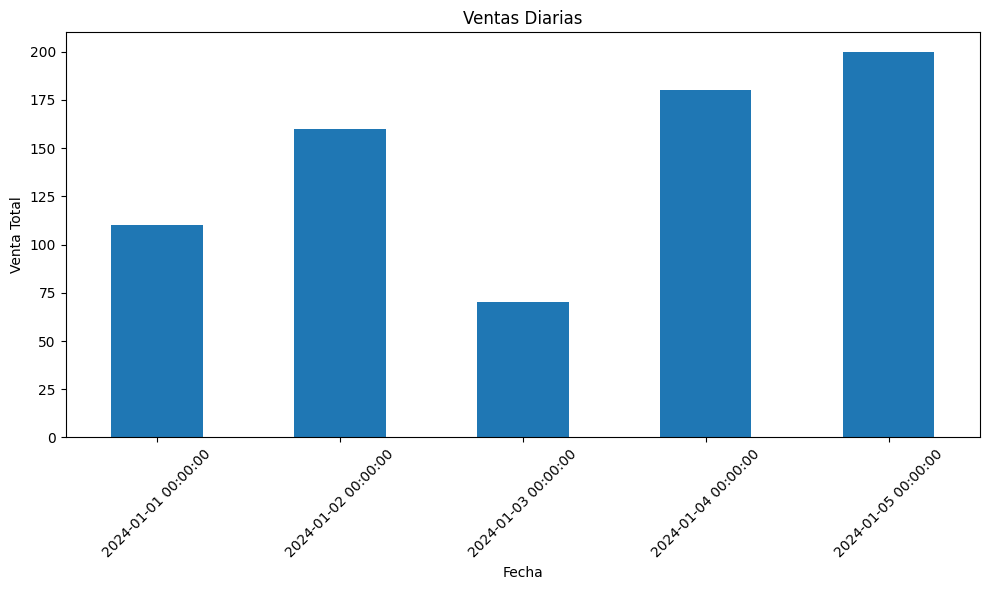

In [32]:
plt.figure(figsize=(10, 6))
ventas_por_dia['venta_total'].plot(kind='bar')
plt.title('Ventas Diarias')
plt.xlabel('Fecha')
plt.ylabel('Venta Total')
plt.xticks(rotation=45)
plt.tight_layout()

### 6.2 Gráfico de Pastel de Ventas por Categoría

Text(0.5, 1.0, 'Distribución de Ventas por Categoría')

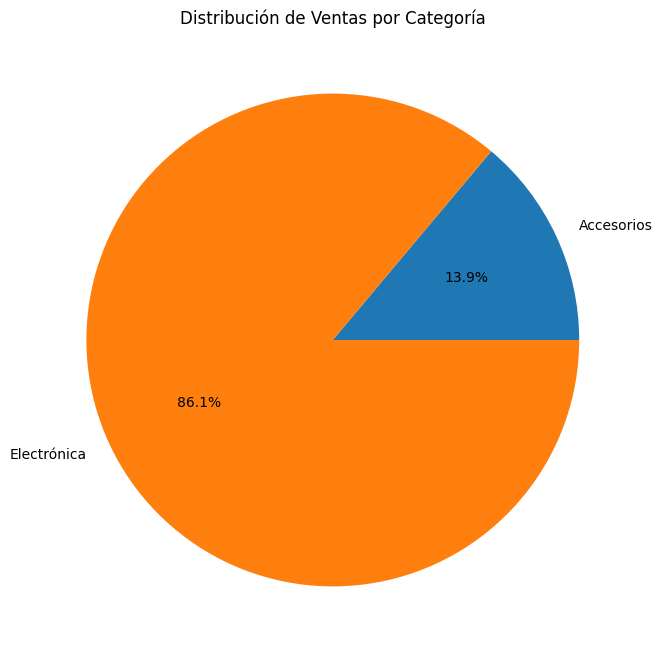

In [44]:
plt.figure(figsize=(8,8))
plt.pie(ventas_por_categoria['venta_total'],
        labels=ventas_por_categoria.index,
        autopct='%1.1f%%')
plt.title('Distribución de Ventas por Categoría')

### 6.3 Gráfico de Barras de Productos más Vendidos

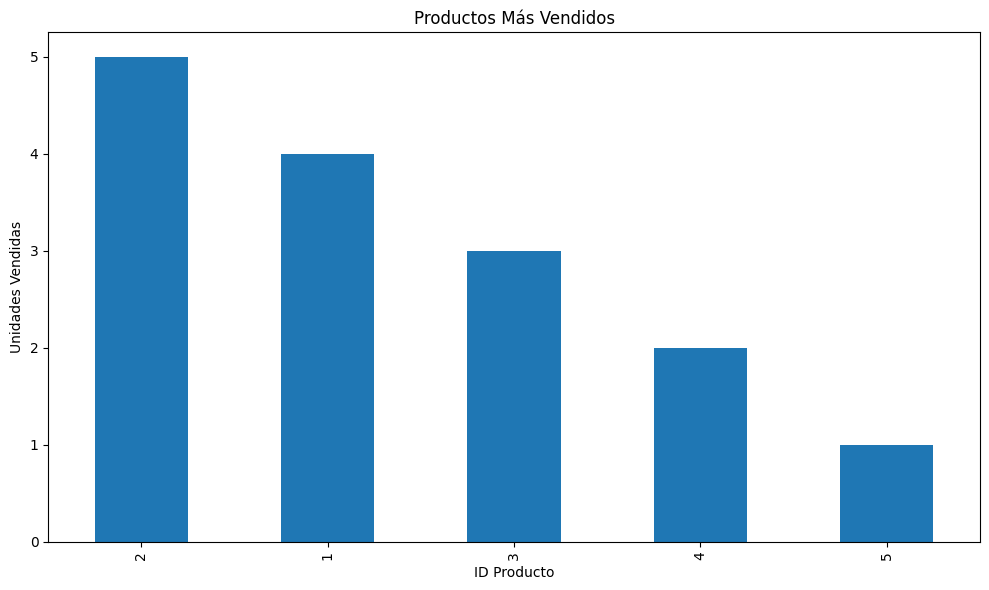

In [45]:
plt.figure(figsize=(10, 6))
productos_mas_vendidos['unidades_vendidas'].plot(kind='bar')
plt.title('Productos Más Vendidos')
plt.xlabel('ID Producto')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()

EJERCICIOS PRÁCTICOS SUGERIDOS:

1. Calcular la tasa de conversión diaria (ventas realizadas / clientes únicos).
2. Analizar la estacionalidad de las ventas por día de la semana.
3. Identificar los productos con bajo stock (< 20 unidades) y sus ventas recientes.
4. Calcular el tiempo promedio entre compras por cliente.
5. Crear un dashboard simple con los KPIs más importantes.
6. Rehacer el gráfico anterior, pero agregando el nombre del producto y no el ID.

##### Calcular tasa de conversión diaria
conversion_diaria = df_ventas.groupby('fecha').agg({
    'id_venta': 'count',
    'id_cliente': 'nunique'
})

conversion_diaria['tasa_conversion'] = (
    conversion_diaria['id_venta'] / conversion_diaria['id_cliente']
).round(2)

print("\nTasa de conversión diaria:")
print(conversion_diaria)

FUNCIONES DE UTILIDAD ADICIONALES
"""

def analizar_producto(id_producto):
    """Función para obtener un análisis completo de un producto específico"""
    # Datos del producto
    producto = df_productos[df_productos['id_producto'] == id_producto].iloc[0]
    
    # Historial de ventas
    ventas_producto = df_ventas[df_ventas['id_producto'] == id_producto]
    
    # Estadísticas
    total_vendido = ventas_producto['cantidad'].sum()
    ingreso_total = (ventas_producto['cantidad'] * ventas_producto['precio_unitario']).sum()
    
    print(f"Análisis del producto: {producto['nombre']}")
    print(f"Categoría: {producto['categoria']}")
    print(f"Stock actual: {producto['stock']}")
    print(f"Total unidades vendidas: {total_vendido}")
    print(f"Ingreso total: ${ingreso_total:,.2f}")
    
    return ventas_producto

def analizar_cliente(id_cliente):
    """Función para obtener un análisis completo de un cliente específico"""
    # Datos del cliente
    cliente = df_clientes[df_clientes['id_cliente'] == id_cliente].iloc[0]
    
    # Historial de compras
    compras_cliente = df_ventas[df_ventas['id_cliente'] == id_cliente]
    
    # Estadísticas
    total_compras = len(compras_cliente)
    gasto_total = (compras_cliente['cantidad'] * compras_cliente['precio_unitario']).sum()
    ticket_promedio = gasto_total / total_compras if total_compras > 0 else 0
    
    print(f"Análisis del cliente: {cliente['nombre']}")
    print(f"Ciudad: {cliente['ciudad']}")
    print(f"Fecha registro: {cliente['fecha_registro']}")
    print(f"Total compras: {total_compras}")
    print(f"Gasto total: ${gasto_total:,.2f}")
    print(f"Ticket promedio: ${ticket_promedio:,.2f}")
    
    return compras_cliente